# FMATCH 1/10 — Radiometer PSF & footprint viewing geometry

**PR topic**: the two foundation modules of the footprint-matching (FMATCH) pipeline,
plus the shared value types they use:

- `libera_utils.footprint_matching.psf` — the CERES-heritage point spread function
  ([CERES ATBD subsystem 4.4, Eq. 4.4-1](https://ceres.larc.nasa.gov/documents/ATBD/pdf/r2_2/ceres-atbd2.2-s4.4.pdf)): how much a scene element at angle (δ, β) from the boresight
  contributes to the radiometer measurement.
- `libera_utils.footprint_matching.geometry` — projecting a footprint's PSF extent
  onto the [WGS84 ellipsoid](https://en.wikipedia.org/wiki/World_Geodetic_System): L1B viewing geometry in, lat/lon `BoundingBox` out.
  Includes the **vectorized batch path** (`compute_footprint_bounding_boxes`) that
  amortizes the [pyproj](https://pyproj4.github.io/pyproj/stable/)/rotation work over a whole granule of footprints.
- `libera_utils.footprint_matching.types` — small immutable value types
  (`BoundingBox`, grid-tile keys) shared by every later FMATCH stage.

Everything below runs with no external data — inputs are synthesized inline.

**Background**: the [Libera mission](https://lasp.colorado.edu/libera/) measures
Earth's radiation budget; FMATCH pairs each radiometer footprint with imager and
ancillary scene information, following the CERES SSF convolution heritage.

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np

from libera_utils.footprint_matching import geometry, psf

## 1. The point spread function

The radiometer does not measure a point: the optical field of view convolved with the
detector's time response smears each measurement over ~1–3° of scan angle. The PSF is
**asymmetric along-scan** — the detector time-response tail trails the scan direction —
and symmetric cross-scan. `psf_weight(delta, beta)` evaluates it on arrays.

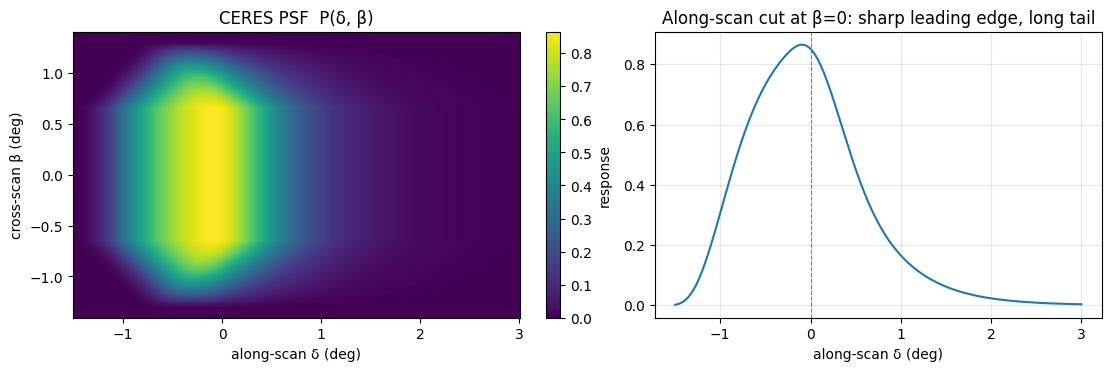

In [2]:
delta = np.linspace(-1.5, 3.0, 451)  # along-scan angle (deg)
beta = np.linspace(-1.4, 1.4, 281)  # cross-scan angle (deg)
dd, bb = np.meshgrid(delta, beta)
weights = psf.psf_weight(dd, bb)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.6), constrained_layout=True)
im = ax1.pcolormesh(delta, beta, weights, shading="auto", cmap="viridis")
ax1.set_xlabel("along-scan δ (deg)")
ax1.set_ylabel("cross-scan β (deg)")
ax1.set_title("CERES PSF  P(δ, β)")
fig.colorbar(im, ax=ax1, label="response")

ax2.plot(delta, psf.psf_weight(delta, np.zeros_like(delta)))
ax2.axvline(0, color="grey", lw=0.8, ls="--")
ax2.set_xlabel("along-scan δ (deg)")
ax2.set_title("Along-scan cut at β=0: sharp leading edge, long tail")
ax2.grid(alpha=0.3)
plt.show()

### The 95%-energy angular extent

For bounding boxes we need "how far does the PSF meaningfully reach". The pipeline
uses the smallest angular region holding 95% of the PSF energy
(`psf_95_energy_extent`, cached — it is a static instrument property). Note the
asymmetry: the extent reaches further *behind* the centroid (`delta_back`) than in
front of it. The optical FOV half-angle is used as a floor (`static_fov_extent`).

In [3]:
extent95 = psf.psf_95_energy_extent()
fov = psf.static_fov_extent()
print(
    f"95% energy extent : δ_back={extent95.delta_back_deg:.3f}°  δ_front={extent95.delta_front_deg:.3f}°  "
    f"β_max={extent95.beta_max_deg:.3f}°"
)
print(
    f"static FOV floor  : δ_back={fov.delta_back_deg:.3f}°  δ_front={fov.delta_front_deg:.3f}°  "
    f"β_max={fov.beta_max_deg:.3f}°"
)

95% energy extent : δ_back=1.240°  δ_front=1.340°  β_max=1.260°
static FOV floor  : δ_back=1.000°  δ_front=1.000°  β_max=1.000°


## 2. From L1B viewing geometry to a ground bounding box

`compute_footprint_bounding_box` takes exactly the fields the Libera L1B product
populates — footprint `Latitude`/`Longitude`, `Subsatellite_Latitude`/`Longitude`,
`Viewing_Zenith_Surface` — and ray-traces the PSF perimeter onto the WGS84
ellipsoid. The result is a `BoundingBox` with dateline/polar handling flags that the
downstream tile manager understands.

Two illustrative cases: a near-nadir footprint and an oblique (VZA 60°) footprint.
Oblique viewing **elongates** the footprint along the scan direction.

In [4]:
near_nadir = geometry.compute_footprint_bounding_box(
    boresight_lat_deg=40.0,
    boresight_lon_deg=-105.0,
    subsatellite_lat_deg=40.0,
    subsatellite_lon_deg=-105.1,
    viewing_zenith_deg=2.0,
)
oblique = geometry.compute_footprint_bounding_box(
    boresight_lat_deg=40.0,
    boresight_lon_deg=-105.0,
    subsatellite_lat_deg=44.5,
    subsatellite_lon_deg=-104.0,
    viewing_zenith_deg=60.0,
)
for name, box in [("near-nadir (VZA≈2°)", near_nadir), ("oblique (VZA=60°)", oblique)]:
    print(
        f"{name:22s} lat [{box.lat_min:7.3f}, {box.lat_max:7.3f}]  "
        f"lon [{box.lon_min:9.3f}, {box.lon_max:9.3f}]  "
        f"dateline={box.wraps_dateline} polar={box.is_polar} truncated={box.truncated}"
    )

near-nadir (VZA≈2°)    lat [ 39.947,  40.053]  lon [ -105.073,  -104.927]  dateline=False polar=False truncated=False
oblique (VZA=60°)      lat [ 39.718,  40.257]  lon [ -105.176,  -104.829]  dateline=False polar=False truncated=False


Edge cases the geometry handles explicitly:

- **Dateline**: a footprint at lon ≈ 180° gets `wraps_dateline=True`; the tile
  manager later issues two sub-requests instead of one absurd 360°-wide box.
- **Poles**: above 85° latitude the box switches to a great-circle construction
  (`is_polar=True`).
- **Off-limb**: a boresight at/beyond the Earth limb raises `OffLimbError`
  (scalar path) or yields `None` (batch path) so the caller can record a fallback.

In [5]:
dateline_box = geometry.compute_footprint_bounding_box(
    boresight_lat_deg=-10.0,
    boresight_lon_deg=179.95,
    subsatellite_lat_deg=-10.0,
    subsatellite_lon_deg=179.5,
    viewing_zenith_deg=30.0,
)
polar_box = geometry.compute_footprint_bounding_box(
    boresight_lat_deg=88.0,
    boresight_lon_deg=10.0,
    subsatellite_lat_deg=86.5,
    subsatellite_lon_deg=10.0,
    viewing_zenith_deg=20.0,
)
print(
    f"dateline: lon [{dateline_box.lon_min:.3f}, {dateline_box.lon_max:.3f}]  wraps_dateline={dateline_box.wraps_dateline}"
)
print(f"polar   : lat [{polar_box.lat_min:.3f}, {polar_box.lat_max:.3f}]  is_polar={polar_box.is_polar}")
try:
    geometry.compute_footprint_bounding_box(
        boresight_lat_deg=0.0,
        boresight_lon_deg=0.0,
        subsatellite_lat_deg=0.0,
        subsatellite_lon_deg=-60.0,
        viewing_zenith_deg=90.0,
    )
except geometry.OffLimbError as err:
    print(f"off-limb: OffLimbError raised as expected — {err}")

dateline: lon [179.924, 179.976]  wraps_dateline=False
polar   : lat [87.878, 88.125]  is_polar=True
off-limb: OffLimbError raised as expected — Viewing zenith angle 90.000 deg is at or beyond the limb (90 deg).


## 3. A synthetic scan: boxes along the ground track

A Libera-like scan sweeps the boresight across-track. Below, a synthetic segment of
~60 footprints sweeps VZA from −65° to +65° while the subsatellite point advances
along the orbit. Watch the boxes grow toward the swath edges (PSF elongation with
viewing zenith).

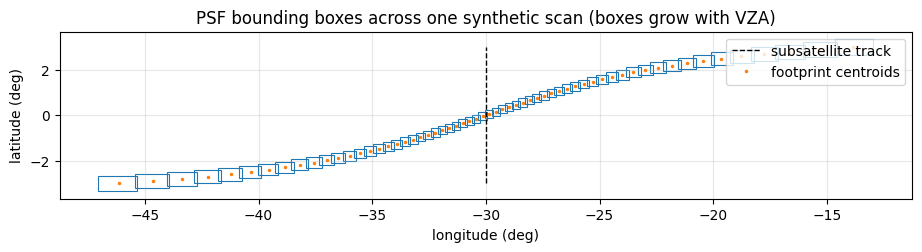

In [6]:
n = 60
track_lat = np.linspace(-3.0, 3.0, n)  # subsatellite point advancing north
track_lon = np.full(n, -30.0)
scan_angle = np.linspace(-65.0, 65.0, n)  # signed viewing zenith across the scan
# Boresight displaced east/west of track proportional to the scan angle.
ground_offset_deg = np.tan(np.radians(scan_angle)) * geometry.NOMINAL_ALTITUDE_KM / 111.0
bore_lat = track_lat
bore_lon = track_lon + ground_offset_deg

boxes = geometry.compute_footprint_bounding_boxes(
    bore_lat,
    bore_lon,
    track_lat,
    track_lon,
    np.abs(scan_angle),
    altitude_km=geometry.NOMINAL_ALTITUDE_KM,
)

fig, ax = plt.subplots(figsize=(11, 4))
for center_lon, box in zip(bore_lon, boxes, strict=True):
    if box is None:
        continue
    ax.add_patch(
        plt.Rectangle(
            (box.lon_min, box.lat_min),
            box.lon_max - box.lon_min,
            box.lat_max - box.lat_min,
            fill=False,
            ec="tab:blue",
            lw=0.8,
        )
    )
ax.plot(track_lon, track_lat, "k--", lw=1, label="subsatellite track")
ax.plot(bore_lon, bore_lat, ".", color="tab:orange", ms=3, label="footprint centroids")
ax.set_xlabel("longitude (deg)")
ax.set_ylabel("latitude (deg)")
ax.set_title("PSF bounding boxes across one synthetic scan (boxes grow with VZA)")
ax.legend(loc="upper right")
ax.set_aspect("equal")
ax.grid(alpha=0.3)
plt.show()

## 4. Why the batch path exists: scalar vs vectorized

`compute_footprint_bounding_boxes` is numerically equivalent to calling the scalar
entry point per footprint (the unit tests assert parity), but it vectorizes the
viewing-geometry solve, the PSF perimeter ray-trace, and the box assembly across all
footprints at once. That is the difference between meeting the granule latency
budget and not.

In [7]:
n = 2000
rng = np.random.default_rng(42)
lat = rng.uniform(-70, 70, n)
lon = rng.uniform(-180, 180, n)
vza = rng.uniform(0, 65, n)
sub_lat = lat + rng.uniform(-3, 3, n)
sub_lon = lon + rng.uniform(-3, 3, n)

t0 = time.perf_counter()
batch = geometry.compute_footprint_bounding_boxes(
    lat, lon, sub_lat, sub_lon, vza, altitude_km=geometry.NOMINAL_ALTITUDE_KM
)
t_batch = time.perf_counter() - t0

n_scalar = 200  # scalar path timed on a subset, then scaled
t0 = time.perf_counter()
scalar = [
    geometry.compute_footprint_bounding_box(
        lat[i], lon[i], sub_lat[i], sub_lon[i], vza[i], altitude_km=geometry.NOMINAL_ALTITUDE_KM
    )
    for i in range(n_scalar)
]
t_scalar = (time.perf_counter() - t0) * (n / n_scalar)

print(f"batch    : {n} footprints in {t_batch:.3f} s")
print(f"scalar   : {n} footprints in {t_scalar:.3f} s (extrapolated from {n_scalar})")
print(f"speed-up : {t_scalar / t_batch:.0f}x")

# Parity spot-check on the subset computed both ways.
for i in range(n_scalar):
    b, s = batch[i], scalar[i]
    if b is None:
        raise ValueError(f"footprint {i}: batch path returned None where scalar path succeeded")
    np.testing.assert_allclose(
        [b.lat_min, b.lat_max, b.lon_min, b.lon_max],
        [s.lat_min, s.lat_max, s.lon_min, s.lon_max],
        atol=1e-6,
    )
print(f"parity   : batch == scalar on {n_scalar} footprints (atol=1e-6)")

batch    : 2000 footprints in 0.153 s
scalar   : 2000 footprints in 6.526 s (extrapolated from 200)
speed-up : 43x
parity   : batch == scalar on 200 footprints (atol=1e-6)


## Where this goes next in the stack

The `BoundingBox`es produced here are consumed by the **tile manager** (which loads
only the ancillary-grid tiles each box touches) and the PSF weights by the
**weighting/aggregation** stage (PSF-weighted footprint statistics). Those arrive in
later PRs of this stack; this PR is self-contained at the geometry/PSF level.